In [72]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [77]:
# Loading the dataset
ucd = pd.read_csv('used_cars_data.csv')

In [91]:
ucd['Price'].fillna(ucd['Price'].median(), inplace=True)


0        175000.0
1       1250000.0
2        450000.0
3        600000.0
4       1774000.0
          ...    
7248     564000.0
7249     564000.0
7250     564000.0
7251     564000.0
7252     564000.0
Name: Price, Length: 7253, dtype: float64

In [74]:
# Basic Data Understanding
print("Dataset Shape:", ucd.shape)
print("\nFirst Few Rows:")
display(ucd.head())
print("\nData Types:")
display(ucd.dtypes)
print("\nDataset Info:")
ucd.info()

Dataset Shape: (7253, 13)

First Few Rows:


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74



Data Types:


S.No.                  int64
Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage                  str
Engine                   str
Power                    str
Seats                float64
Price                float64
dtype: object


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   str    
 2   Location           7253 non-null   str    
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   str    
 6   Transmission       7253 non-null   str    
 7   Owner_Type         7253 non-null   str    
 8   Mileage            7251 non-null   str    
 9   Engine             7207 non-null   str    
 10  Power              7207 non-null   str    
 11  Seats              7200 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(3), str(8)
memory usage: 736.8 KB


In [78]:
# FIXING DATA TYPES AND CORRECTING NAMES OF THE FEATURES
# Drop S.No. as it is not useful for analysis
ucd.drop(columns=['S.No.'], inplace=True)

# Remove 'kmpl' from Mileage column and convert to numeric
ucd['Mileage'] = ucd['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Mileage': 'Mileage_Kmpl'}, inplace=True)

# Remove 'CC' from Engine column and convert to numeric
ucd['Engine'] = ucd['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Engine': 'Engine_CC'}, inplace=True)

# Remove 'bhp' from Power column and convert to numeric
ucd['Power'] = ucd['Power'].str.extract(r'(\d+\.?\d*)').astype(float)
ucd.rename(columns={'Power': 'Power_bhp'}, inplace=True)

# Convert Price from Lakh to actual rupees (multiply by 100,000)
ucd['Price'] = ucd['Price'] * 100000


In [79]:
# DISPLAYING THE FIXED DATASET
ucd.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_Kmpl,Engine_CC,Power_bhp,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,175000.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,1250000.0
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,450000.0
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,600000.0
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,1774000.0


In [80]:
# DESCRIPTIVE STATISTICS OF THE DATASET
ucd.describe()

,Year,Kilometers_Driven,Mileage_Kmpl,Engine_CC,Power_bhp,Seats,Price
count,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,6.019000e+03
mean,2013.365366,5.869906e+04,18.141580,1616.573470,112.765214,5.279722,9.479468e+05
std,3.254421,8.442772e+04,4.562197,595.285137,53.493553,0.811660,1.118792e+06
min,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,0.000000,4.400000e+04
25%,2011.000000,3.400000e+04,15.170000,1198.000000,75.000000,5.000000,3.500000e+05
50%,2014.000000,5.341600e+04,18.160000,1493.000000,94.000000,5.000000,5.640000e+05
75%,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,9.950000e+05
max,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,1.600000e+07


In [81]:
# Missing Values Analysis
print("Missing Values:")
missing_df = pd.DataFrame({
    'Column': ucd.columns,
    'Missing_Count': ucd.isnull().sum(),
    'Missing_Percentage': (ucd.isnull().sum() / len(ucd) * 100).round(2)
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))
print("\nStatistical Summary:")
print(ucd.describe())

Missing Values:
                    Column  Missing_Count  Missing_Percentage
Price                Price           1234               17.01
Power_bhp        Power_bhp            175                2.41
Seats                Seats             53                0.73
Engine_CC        Engine_CC             46                0.63
Mileage_Kmpl  Mileage_Kmpl              2                0.03

Statistical Summary:
              Year  Kilometers_Driven  Mileage_Kmpl    Engine_CC    Power_bhp  \
count  7253.000000       7.253000e+03   7251.000000  7207.000000  7078.000000   
mean   2013.365366       5.869906e+04     18.141580  1616.573470   112.765214   
std       3.254421       8.442772e+04      4.562197   595.285137    53.493553   
min    1996.000000       1.710000e+02      0.000000    72.000000    34.200000   
25%    2011.000000       3.400000e+04     15.170000  1198.000000    75.000000   
50%    2014.000000       5.341600e+04     18.160000  1493.000000    94.000000   
75%    2016.000000     

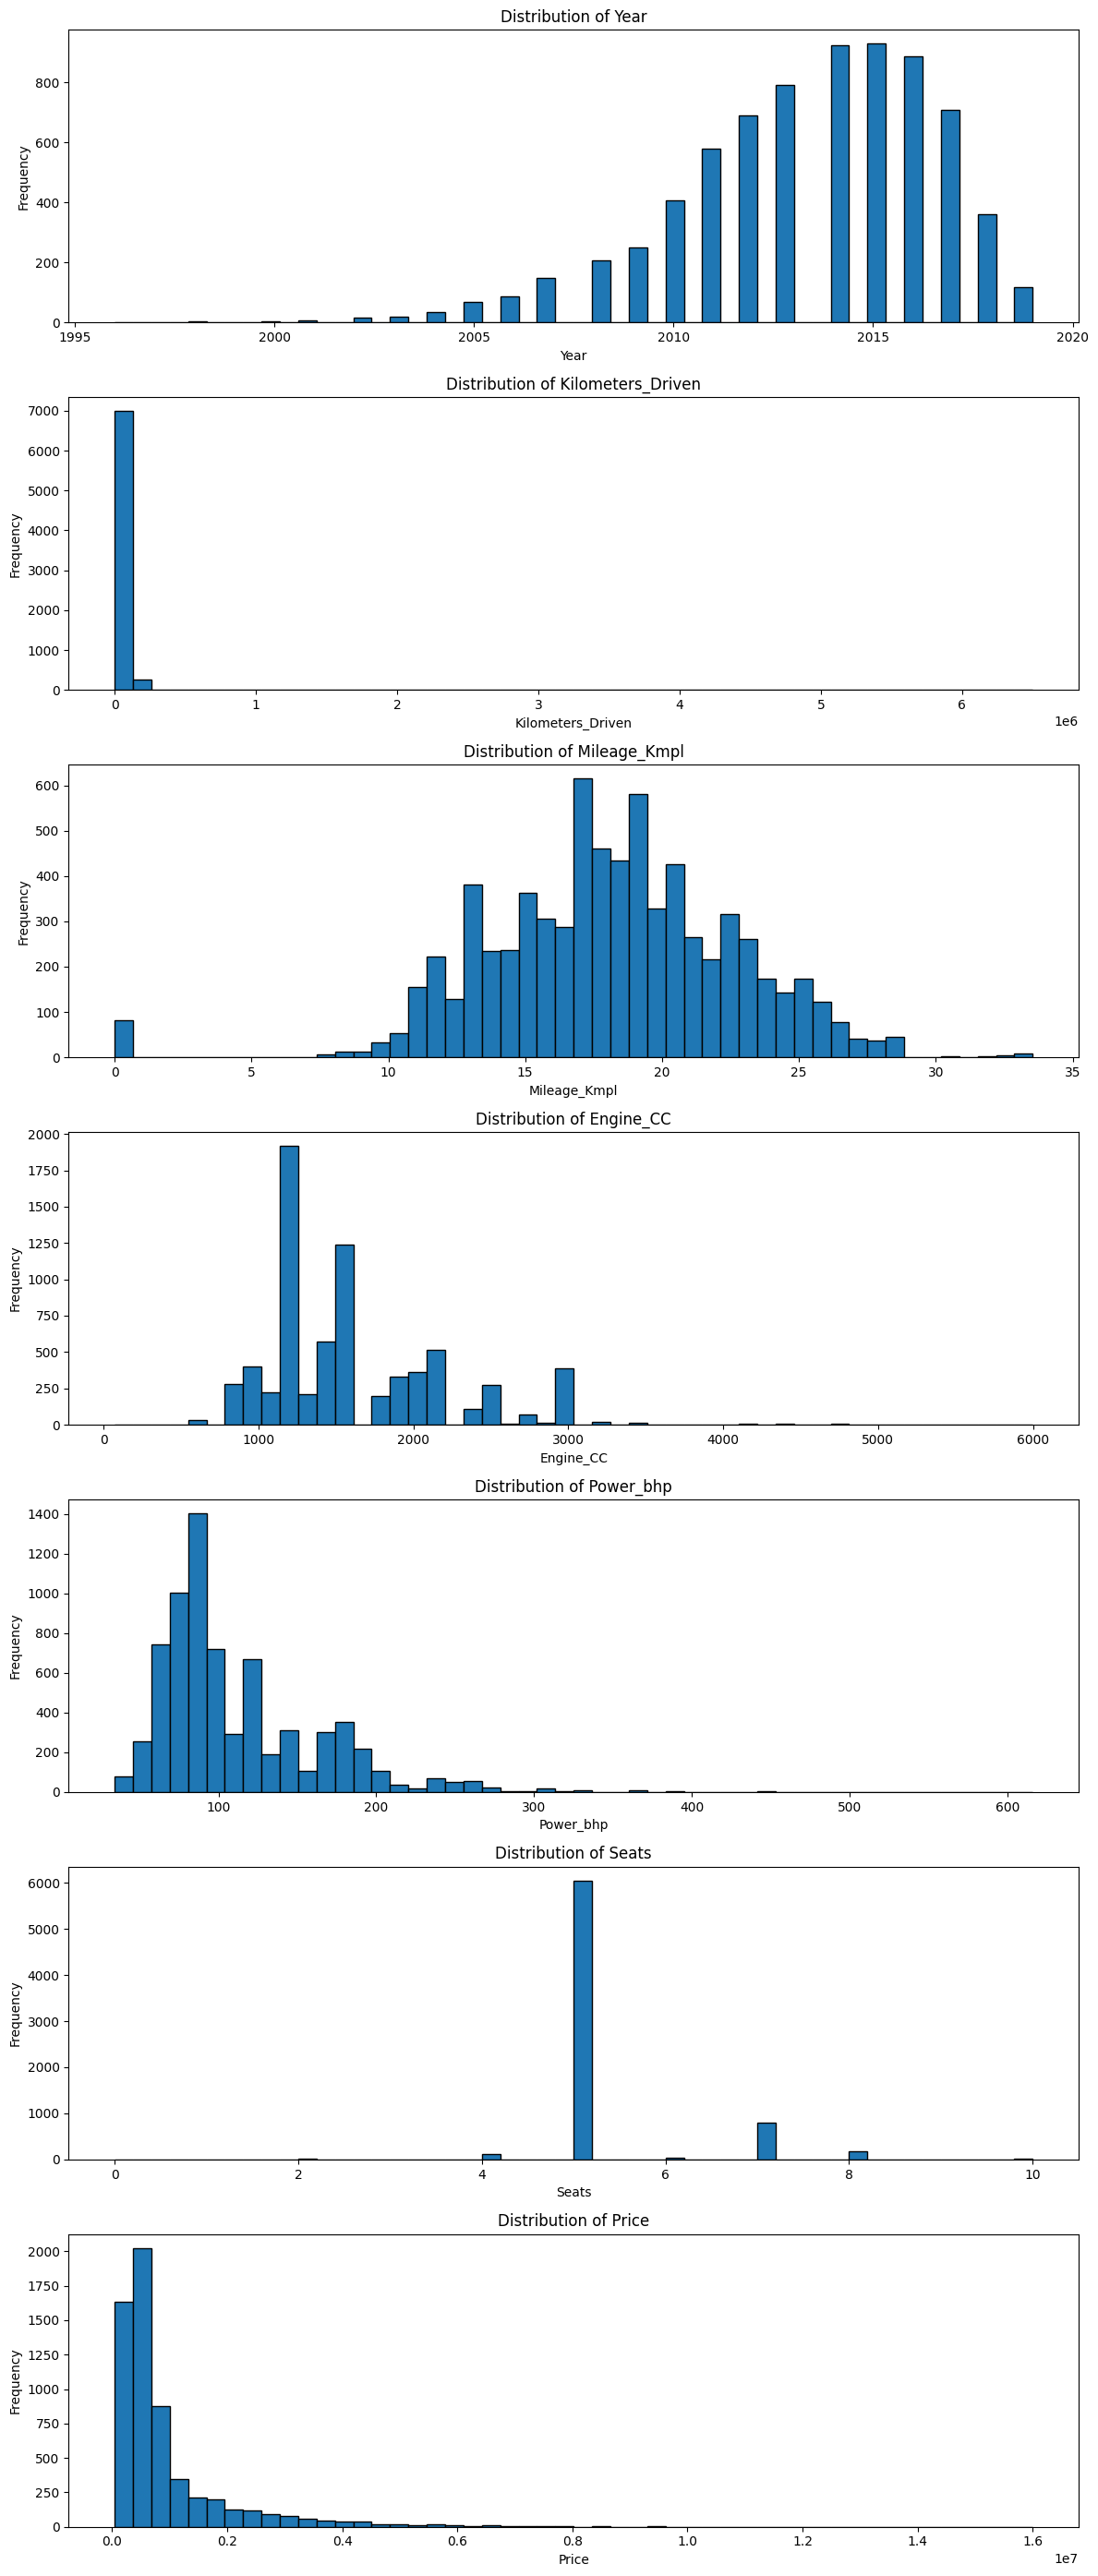

In [82]:
# Numerical Columns Distribution Analysis
numeric_cols = ucd.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(ucd[col].dropna(), bins=50, edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Categorical Columns Analysis
categorical_cols = ucd.select_dtypes(include=['object']).columns
print("Categorical Columns Unique Values:")
for col in categorical_cols:
    print(f"\n{col}: {ucd[col].nunique()} unique values")
    print(ucd[col].value_counts().head(10))

In [ ]:
# Correlation Analysis
numeric_data = ucd.select_dtypes(include=[np.number])
if len(numeric_data.columns) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    
print("\nHighest Correlations with Numeric Columns:")
print(numeric_data.corr().abs().unstack().sort_values(ascending=False).head(10))

In [ ]:
# Outlier Detection (IQR Method)
print("Outlier Detection (IQR Method):")
for col in numeric_cols:
    Q1 = ucd[col].quantile(0.25)
    Q3 = ucd[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ucd[(ucd[col] < lower_bound) | (ucd[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"\n{col}: {len(outliers)} outliers ({len(outliers)/len(ucd)*100:.2f}%)")
        
# Data Quality Summary
print("\n" + "="*50)
print("DATA QUALITY SUMMARY")
print("="*50)
print(f"Total Records: {len(ucd)}")
print(f"Total Features: {len(ucd.columns)}")
print(f"Duplicate Rows: {ucd.duplicated().sum()}")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
